In [1]:
# ==================== CELL 1: Setup, training, and attack utilities ====================
import os
import random
import ast
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------- Load dataset (your original file) ----------
CSV_PATH = "all_circuits_features.csv"   # keep your filename
df = pd.read_csv(CSV_PATH)

print("\nDataset head:")
print(df.head())

# ---------- Label encode gate_type if present ----------
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# ---------- Feature columns (same as yours) ----------
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

# Drop NaNs and cast
df = df.dropna(subset=feature_columns).reset_index(drop=True)
df[feature_columns] = df[feature_columns].astype(float)

# Standardize features (same as earlier)
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# ---------- Build nodes and mapping (keeps your original "node" use) ----------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

# ---------- Build edges using your original approximate approach (Option B) ----------
edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))  # src -> node

print(f"\nExtracted {len(edges)} edges (approximate fan-in construction).")
if len(edges) == 0:
    raise ValueError("No edges found! Check 'fan_in'/'fan_out' in CSV.")

src_nodes, dst_nodes = zip(*edges) if edges else ([], [])
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

# Validate edges
valid_edges = (src_tensor >= 0) & (dst_tensor >= 0) & (src_tensor < len(nodes)) & (dst_tensor < len(nodes))
src_tensor = src_tensor[valid_edges]
dst_tensor = dst_tensor[valid_edges]

# ---------- Create DGL graph and add self-loop (graph variable reserved) ----------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)  # ensure non-zero in-degree

# Assign features and labels (keep on CPU for now; we will move model/graph to device below)
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# ---------- Train-test split: create index arrays and boolean masks ----------
num_nodes = graph.num_nodes()
indices = np.arange(num_nodes)
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=SEED)
# boolean masks for indexing (preferred)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

# ---------- Define GCN (same architecture as yours) ----------
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_feats, out_feats, allow_zero_in_degree=True)
    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GCN(in_feats, hidden_feats, out_feats)

# ---------- Move model & graph to device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
graph = graph.to(device)
graph.ndata['features'] = graph.ndata['features'].to(device)
graph.ndata['labels'] = graph.ndata['labels'].to(device)
train_mask = train_mask.to(device)
test_mask = test_mask.to(device)

# ---------- Training setup (same as your original) ----------
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# Training loop (you had epochs=50)
epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    # use boolean masks for indexing
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# Evaluate quick
model.eval()
with torch.no_grad():
    logits_all = model(graph, graph.ndata['features'])
    test_pred = logits_all[test_mask].argmax(dim=1)
    test_acc = (test_pred == graph.ndata['labels'][test_mask]).float().mean().item()
    train_pred = logits_all[train_mask].argmax(dim=1)
    train_acc = (train_pred == graph.ndata['labels'][train_mask]).float().mean().item()
print(f"\nTest Accuracy: {test_acc*100:.2f}%, Train Accuracy: {train_acc*100:.2f}%")

# ---------- Attack utility functions (robust) ----------
EPS = 1e-8

def compute_true_grads(model, graph, target_idx):
    """
    Compute gradients of single-node loss wrt model parameters for target_idx.
    Returns list of tensors (one per parameter), detached.
    """
    model.zero_grad()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[target_idx:target_idx+1], graph.ndata['labels'][target_idx:target_idx+1])
    grads = torch.autograd.grad(loss, tuple(model.parameters()), allow_unused=True)
    # replace None with zeros of corresponding param shape
    grads_filled = []
    for p, g in zip(model.parameters(), grads):
        if g is None:
            grads_filled.append(torch.zeros_like(p).detach())
        else:
            grads_filled.append(g.detach().clone())
    return grads_filled

def grad_inversion_with_target_grads(model, graph, target_idx, grads_target_mod,
                                     steps=300, lr=0.05, l2_reg=1e-3,
                                     normalize_paramwise=True, clamp_range=5.0, early_stop_patience=40,
                                     verbose=False):
    """
    Reconstruct features for target_idx by matching model-parameter gradients to grads_target_mod.
    Returns reconstructed feature (cpu Tensor) and metrics dict (abs_l2, rel_l2, cos_sim).
    """
    model.eval()
    X_orig = graph.ndata['features'].detach()
    x_true = X_orig[target_idx:target_idx+1].detach().to(device)
    y_true = graph.ndata['labels'][target_idx:target_idx+1].detach().to(device)

    # per-parameter normalization weights (to avoid large layers dominating)
    param_sizes = [max(p.numel(), 1) for p in model.parameters()]

    # initialize dummy feature
    x_rec = torch.randn_like(x_true, requires_grad=True, device=device)
    optimizer_rec = optim.Adam([x_rec], lr=lr)

    best_loss = float('inf')
    best_x = None
    stale = 0

    for it in range(steps):
        optimizer_rec.zero_grad()
        # build dummy feature matrix and forward
        X_mod = X_orig.clone()
        X_mod[target_idx:target_idx+1] = x_rec
        logits_mod = model(graph, X_mod)
        loss_mod = loss_fn(logits_mod[target_idx:target_idx+1], y_true)

        # compute grads wrt model.params (create_graph=True to allow backprop to x_rec)
        grads_rec = torch.autograd.grad(loss_mod, tuple(model.parameters()), create_graph=True, allow_unused=True)

        # compute normalized grad-diff loss
        total = torch.tensor(0.0, device=device)
        for i, (gr_rec, gr_tgt) in enumerate(zip(grads_rec, grads_target_mod)):
            if gr_rec is None:
                continue
            gt = gr_tgt.to(device)
            gr = gr_rec
            if normalize_paramwise:
                total = total + ((gr - gt).pow(2).sum() / (float(gt.numel()) + EPS))
            else:
                total = total + ((gr - gt).pow(2).sum())

        reg = l2_reg * torch.norm(x_rec, p=2)
        objective = total + reg

        objective.backward()
        optimizer_rec.step()

        # clamp to avoid runaway values
        with torch.no_grad():
            x_rec.clamp_(-clamp_range, clamp_range)

        cur_loss = objective.item()
        if cur_loss < best_loss - 1e-7:
            best_loss = cur_loss
            best_x = x_rec.detach().clone()
            stale = 0
        else:
            stale += 1
            if stale >= early_stop_patience:
                if verbose:
                    print(f"Early stopping at iter {it} (best_loss={best_loss:.6f})")
                break

        if verbose and (it % 50 == 0):
            print(f"iter {it} objective {cur_loss:.6f}")

    if best_x is None:
        best_x = x_rec.detach().clone()

    # metrics
    abs_l2 = torch.norm(best_x - x_true).item()
    rel_l2 = abs_l2 / (torch.norm(x_true).item() + EPS)
    cos_sim = (torch.nn.functional.cosine_similarity(best_x.view(-1), x_true.view(-1), dim=0).item())

    return best_x.cpu(), {"abs_l2": abs_l2, "rel_l2": rel_l2, "cos_sim": cos_sim}

# ---------- Sample up to 20 train nodes per class and save sampling (so defense cells can reuse) ----------
unique_labels = torch.unique(graph.ndata['labels']).cpu().numpy()
sampled_nodes_per_label = {}
for lbl in unique_labels:
    train_indices = torch.where(train_mask & (graph.ndata['labels'] == int(lbl)))[0].cpu().numpy().tolist()
    if len(train_indices) == 0:
        sampled = []
    else:
        k = min(20, len(train_indices))
        sampled = random.sample(train_indices, k)
    sampled_nodes_per_label[int(lbl)] = sampled
    pretty_name = label_encoder.inverse_transform([int(lbl)])[0]
    print(f"Label {int(lbl)} ({pretty_name}): sampling {len(sampled)} nodes")

# Save sampled nodes mapping to disk for reuse by defense-specific cells (avoids recompute)
np.save("sampled_nodes_per_label.npy", sampled_nodes_per_label)
print("\nSaved sampled nodes mapping to 'sampled_nodes_per_label.npy'.")

# ---------- Mark completion ----------
print("\nCELL 1 complete. You can now run separate cells for each defense. Variables available in the session:")
print(" - graph, model, train_mask, test_mask, label_encoder, sampled_nodes_per_label")
print(" - compute_true_grads(model, graph, idx)")
print(" - grad_inversion_with_target_grads(model, graph, idx, grads_target_mod, ...)")



Dataset head:
  circuit_name node gate_type  fan_in  fan_out  \
0      adder.v   g1       not       1        1   
1      adder.v   g2       and       2        1   
2      adder.v   g3       not       1        1   
3      adder.v   g4       and       2        1   
4      adder.v   g5        or       2        1   

                                      depth  dist_to_output  is_primary_input  \
0  {'g1': 0, 'g2': 1, 'g5': 2, '\\f[0]': 3}               3                 0   
1           {'g2': 0, 'g5': 1, '\\f[0]': 2}               2                 0   
2  {'g3': 0, 'g4': 1, 'g5': 2, '\\f[0]': 3}               3                 0   
3           {'g4': 0, 'g5': 1, '\\f[0]': 2}               2                 0   
4                    {'g5': 0, '\\f[0]': 1}               1                 0   

   is_primary_output  is_internal  is_key_gate key_dependency  \
0                  0            1            0            NaN   
1                  0            1            0            NaN   
2 


GCN MODEL PERFORMANCE METRICS
Training Accuracy: 0.9245
Test Accuracy: 0.9243

Confusion Matrix:


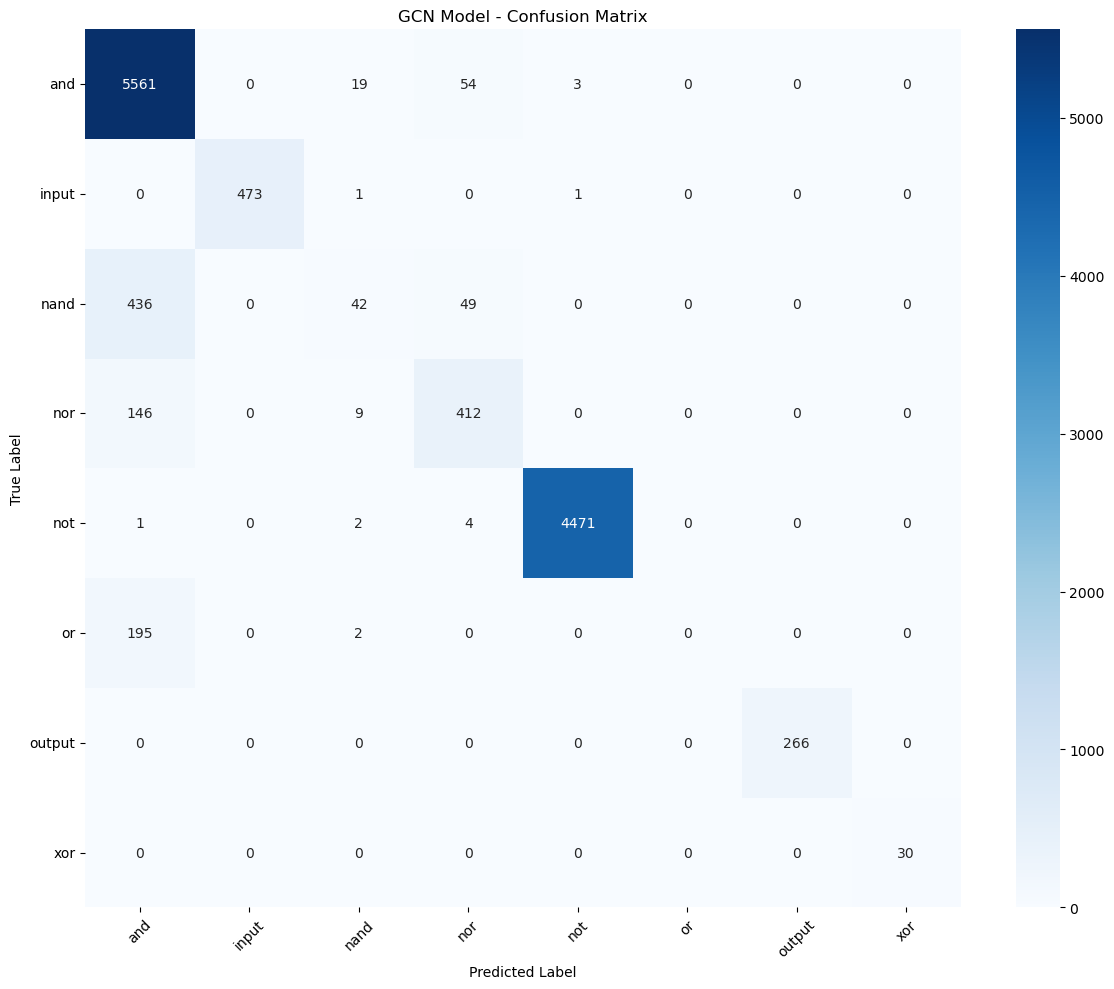


Classification Report:
              precision    recall  f1-score   support

         and       0.88      0.99      0.93      5637
       input       1.00      1.00      1.00       475
        nand       0.56      0.08      0.14       527
         nor       0.79      0.73      0.76       567
         not       1.00      1.00      1.00      4478
          or       0.00      0.00      0.00       197
      output       1.00      1.00      1.00       266
         xor       1.00      1.00      1.00        30

    accuracy                           0.92     12177
   macro avg       0.78      0.72      0.73     12177
weighted avg       0.90      0.92      0.90     12177


Overall Metrics:
Precision: 0.8980
Recall: 0.9243
F1-Score: 0.9018

Per-class Metrics:
Class and: Precision=0.8773, Recall=0.9865, F1=0.9287
Class input: Precision=1.0000, Recall=0.9958, F1=0.9979
Class nand: Precision=0.5600, Recall=0.0797, F1=0.1395
Class nor: Precision=0.7938, Recall=0.7266, F1=0.7587
Class not: Precisi

/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [2]:
# Add these imports if not already present
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns

# -----------------------------------
# Evaluate GCN Model Performance
# -----------------------------------

print("\n" + "="*50)
print("GCN MODEL PERFORMANCE METRICS")
print("="*50)

# Get predictions
model.eval()
with torch.no_grad():
    # Training predictions
    train_logits = model(graph, graph.ndata['features'])
    train_pred = train_logits[train_mask].argmax(dim=1)
    train_labels = graph.ndata['labels'][train_mask]
    train_accuracy = (train_pred == train_labels).float().mean().item()
    
    # Test predictions
    test_logits = model(graph, graph.ndata['features'])
    test_pred = test_logits[test_mask].argmax(dim=1)
    test_labels = graph.ndata['labels'][test_mask]
    test_accuracy = (test_pred == test_labels).float().mean().item()

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Convert to CPU numpy for sklearn metrics
test_pred_np = test_pred.cpu().numpy()
test_labels_np = test_labels.cpu().numpy()
train_pred_np = train_pred.cpu().numpy()
train_labels_np = train_labels.cpu().numpy()

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(test_labels_np, test_pred_np)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('GCN Model - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels_np, test_pred_np, 
                          target_names=label_encoder.classes_))

# Overall Precision, Recall, F1-Score
overall_precision = precision_score(test_labels_np, test_pred_np, average='weighted')
overall_recall = recall_score(test_labels_np, test_pred_np, average='weighted')
overall_f1 = f1_score(test_labels_np, test_pred_np, average='weighted')

print("\nOverall Metrics:")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1-Score: {overall_f1:.4f}")

# Per-class metrics
print("\nPer-class Metrics:")
precision_per_class = precision_score(test_labels_np, test_pred_np, average=None)
recall_per_class = recall_score(test_labels_np, test_pred_np, average=None)
f1_per_class = f1_score(test_labels_np, test_pred_np, average=None)

for i, class_name in enumerate(label_encoder.classes_):
    print(f"Class {class_name}: Precision={precision_per_class[i]:.4f}, "
          f"Recall={recall_per_class[i]:.4f}, F1={f1_per_class[i]:.4f}")

# Additional: Training vs Test accuracy comparison
print(f"\nAccuracy Comparison:")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Gap: {abs(train_accuracy - test_accuracy)*100:.2f}%")

# Class distribution in test set
unique, counts = np.unique(test_labels_np, return_counts=True)
print(f"\nClass distribution in test set:")
for i, count in zip(unique, counts):
    class_name = label_encoder.inverse_transform([i])[0]
    print(f"  {class_name}: {count} samples ({count/len(test_labels_np)*100:.1f}%)")

#### No defense (Baseline)

In [3]:
# CELL 2: No defense (baseline)
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# Parameters
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

# Load sampled nodes
sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()

rows = []
total = sum(len(v) for v in sampled_nodes_per_label.values())
print("Total baseline attacks to run:", total)

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"NoDef label {label_name}"):
        # compute true grads
        grads_true = compute_true_grads(model, graph, target_idx)
        # observed grads = true grads (no defense)
        grads_obs = [g.clone() for g in grads_true]
        # run grad inversion
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "None",
            "defense_key": "none",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_none = pd.DataFrame(rows)
df_none.to_csv("results_none.csv", index=False)
print("Saved results_none.csv (rows: {})".format(len(df_none)))

# Print per-class summary
print("\nBaseline summary (mean ± std):")
print(df_none.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


Total baseline attacks to run: 160


NoDef label xor: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [04:12<00:00, 12.61s/it]

Saved results_none.csv (rows: 160)

Baseline summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.276606  1.541871    20  1.061423  0.632271    20  0.491526   
input        5.260729  0.523064    20  0.767328  0.078851    20  0.675395   
nand         1.811306  1.466285    20  0.768452  0.477102    20  0.725632   
nor          3.035530  1.448231    20  0.742984  0.264765    20  0.600576   
not          2.430037  0.630405    20  1.458293  0.565347    20  0.256930   
or           1.447714  1.139129    20  0.651424  0.506557    20  0.758974   
output       6.265736  0.836566    20  0.745756  0.096251    20  0.756606   
xor         22.058545  1.101236    20  0.939329  0.029295    20  0.739529   

                            
                 std count  
label_name                 

#### Gradient Clipping + Perturbation

In [5]:
# CELL 3: Gradient Clipping + Perturbation
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# Defense hyperparams
clip_value = 1.0
perturb_std = 0.05

# Attack params (same as previous)
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []
total = sum(len(v) for v in sampled_nodes_per_label.values())
print("Total grad-clip attacks to run:", total)

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"GradClip label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = []
        for g in grads_true:
            # clip elementwise between [-clip_value, clip_value] (or use norm-based clipping if you prefer)
            g_clipped = torch.clamp(g, -clip_value, clip_value)
            g_noisy = g_clipped + torch.randn_like(g_clipped) * perturb_std
            grads_obs.append(g_noisy)
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Gradient Clipping + Perturbation",
            "defense_key": "clip_perturb",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_clip = pd.DataFrame(rows)
df_clip.to_csv("results_gradclip_perturb.csv", index=False)
print("Saved results_gradclip_perturb.csv (rows: {})".format(len(df_clip)))

print("\nGradClip summary (mean ± std):")
print(df_clip.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


Total grad-clip attacks to run: 160


GradClip label xor: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [04:05<00:00, 12.27s/it]

Saved results_gradclip_perturb.csv (rows: 160)

GradClip summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.409182  1.301447    20  1.141404  0.541043    20  0.410362   
input        5.426610  0.743144    20  0.790786  0.103353    20  0.648015   
nand         2.298779  1.681308    20  1.013692  0.599143    20  0.599214   
nor          3.353412  1.622858    20  0.807984  0.257170    20  0.614036   
not          1.894063  0.804840    20  1.056003  0.323152    20  0.487685   
or           1.359691  1.387727    20  0.504747  0.265324    20  0.868682   
output       6.423100  0.832684    20  0.764610  0.096424    20  0.727968   
xor         22.620754  1.003425    20  0.963278  0.021118    20  0.617590   

                            
                 std count  
label_name     

#### Differential Privacy (add Gaussian noise to grads)

In [6]:
# CELL 4: Differential Privacy (Gaussian noise)
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# DP hyperparams
dp_sigma = 0.1   # noise multiplier; tune as needed

# Attack params
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"DP label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [g + torch.randn_like(g) * dp_sigma for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Differential Privacy",
            "defense_key": "dp",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_dp = pd.DataFrame(rows)
df_dp.to_csv("results_dp.csv", index=False)
print("Saved results_dp.csv (rows: {})".format(len(df_dp)))

print("\nDP summary (mean ± std):")
print(df_dp.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


DP label xor: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [03:54<00:00, 11.74s/it]

Saved results_dp.csv (rows: 160)

DP summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.274379  1.244399    20  1.066800  0.456057    20  0.460226   
input        5.575439  0.597604    20  0.812958  0.086705    20  0.605073   
nand         2.224429  1.696086    20  0.939509  0.565363    20  0.599781   
nor          3.046519  1.661924    20  0.741950  0.285327    20  0.618243   
not          2.290573  1.345662    20  1.252014  0.581902    20  0.342513   
or           1.339611  1.125519    20  0.572102  0.277749    20  0.808127   
output       6.544791  1.070514    20  0.779103  0.125526    20  0.631504   
xor         22.158015  1.252172    20  0.943198  0.027311    20  0.765440   

                            
                 std count  
label_name                  
and   

#### Secure Aggregation (simulate averaged gradients over group)

In [7]:
# CELL 5: Secure Aggregation (group-average simulated)
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import random

group_size = 5   # group size to simulate aggregation

# Attack params
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

# Build list of train indices per label for sampling group members
all_labels = graph.ndata['labels'].cpu().numpy()
train_indices = torch.where(train_mask)[0].cpu().numpy()
label_to_trainlist = {}
for lbl in np.unique(all_labels):
    label_to_trainlist[int(lbl)] = np.intersect1d(np.where(all_labels==lbl)[0], train_indices).tolist()

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"SecAgg label {label_name}"):
        # sample group of nodes of same label (include target)
        pool = label_to_trainlist.get(int(lbl), [])
        if len(pool) == 0:
            grads_obs = compute_true_grads(model, graph, target_idx)
        else:
            # ensure target included; sample up to group_size-1 more
            members = [target_idx]
            others = [i for i in pool if i != target_idx]
            k = min(len(others), group_size-1)
            if k>0:
                members += random.sample(others, k)
            # compute grads for each member and average
            agg = None
            for m in members:
                g_m = compute_true_grads(model, graph, m)
                if agg is None:
                    agg = [t.clone() for t in g_m]
                else:
                    agg = [a + b for a,b in zip(agg, g_m)]
            grads_obs = [a / float(len(members)) for a in agg]

        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Secure Aggregation",
            "defense_key": "secure_agg",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_secure = pd.DataFrame(rows)
df_secure.to_csv("results_secureagg.csv", index=False)
print("Saved results_secureagg.csv (rows: {})".format(len(df_secure)))

print("\nSecureAgg summary (mean ± std):")
print(df_secure.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


SecAgg label xor: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [04:02<00:00, 12.12s/it]

Saved results_secureagg.csv (rows: 160)

SecureAgg summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.497152  1.543094    20  1.117825  0.444029    20  0.328843   
input        5.548119  0.596408    20  0.808892  0.086140    20  0.604757   
nand         2.704740  1.847698    20  1.183306  0.558424    20  0.400578   
nor          3.543328  1.362808    20  0.886322  0.179013    20  0.461562   
not          2.317420  0.955331    20  1.339610  0.592725    20  0.285220   
or           2.033432  1.094020    20  0.924277  0.323084    20  0.550123   
output       6.414524  0.829943    20  0.764680  0.105221    20  0.688696   
xor         22.428661  0.979525    20  0.955134  0.021589    20  0.675456   

                            
                 std count  
label_name           

#### Model Quantization (round gradients)

In [8]:
# CELL 6: Model Quantization (quantize gradients)
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# quantization params
quant_factor = 100.0   # round to 2 decimal places (1/quant_factor)

# Attack params
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"Quant label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [torch.round(g * quant_factor) / quant_factor for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Model Quantization",
            "defense_key": "quant",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_quant = pd.DataFrame(rows)
df_quant.to_csv("results_quant.csv", index=False)
print("Saved results_quant.csv (rows: {})".format(len(df_quant)))

print("\nQuant summary (mean ± std):")
print(df_quant.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


Quant label xor: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [07:09<00:00, 21.47s/it]

Saved results_quant.csv (rows: 160)

Quant summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.394730  1.262983    20  1.171423  0.640706    20  0.429015   
input        5.430084  0.712591    20  0.791295  0.099896    20  0.626584   
nand         1.700894  1.699355    20  0.597980  0.219749    20  0.791217   
nor          3.008023  1.483177    20  0.728543  0.236004    20  0.655865   
not          2.103269  1.031442    20  1.182024  0.586101    20  0.394054   
or           1.566779  1.301262    20  0.636471  0.313470    20  0.768383   
output       6.266793  0.962539    20  0.745022  0.104772    20  0.740110   
xor         22.387453  1.235835    20  0.953139  0.031862    20  0.611660   

                            
                 std count  
label_name                  


#### Adversarial Training-like Perturbation (small sign noise on grads)

In [9]:
# CELL 7: Adversarial-training style perturbation (sign noise)
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

perturb_eps = 0.02

# Attack params
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"AdvTrain label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [g + perturb_eps * torch.sign(torch.randn_like(g)) for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Adversarial Training",
            "defense_key": "adv_train",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_advtrain = pd.DataFrame(rows)
df_advtrain.to_csv("results_advtrain.csv", index=False)
print("Saved results_advtrain.csv (rows: {})".format(len(df_advtrain)))

print("\nAdvTrain summary (mean ± std):")
print(df_advtrain.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


AdvTrain label xor: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [06:25<00:00, 19.25s/it]

Saved results_advtrain.csv (rows: 160)

AdvTrain summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.544034  1.598957    20  1.142444  0.552965    20  0.387011   
input        5.375384  0.590474    20  0.783994  0.088258    20  0.661316   
nand         1.867766  1.482777    20  0.746759  0.450446    20  0.700278   
nor          3.031427  1.478131    20  0.741527  0.245190    20  0.658945   
not          2.125463  1.263336    20  1.129893  0.450184    20  0.333946   
or           1.211335  1.039843    20  0.518573  0.277745    20  0.866780   
output       6.140001  0.822780    20  0.730307  0.089078    20  0.767581   
xor         22.293483  1.251503    20  0.949348  0.038220    20  0.686715   

                            
                 std count  
label_name             

#### Final plotting: one figure per defense, each with three subplots (abs_l2, rel_l2, cos_sim)

/tmp/ipykernel_43461/4111151762.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


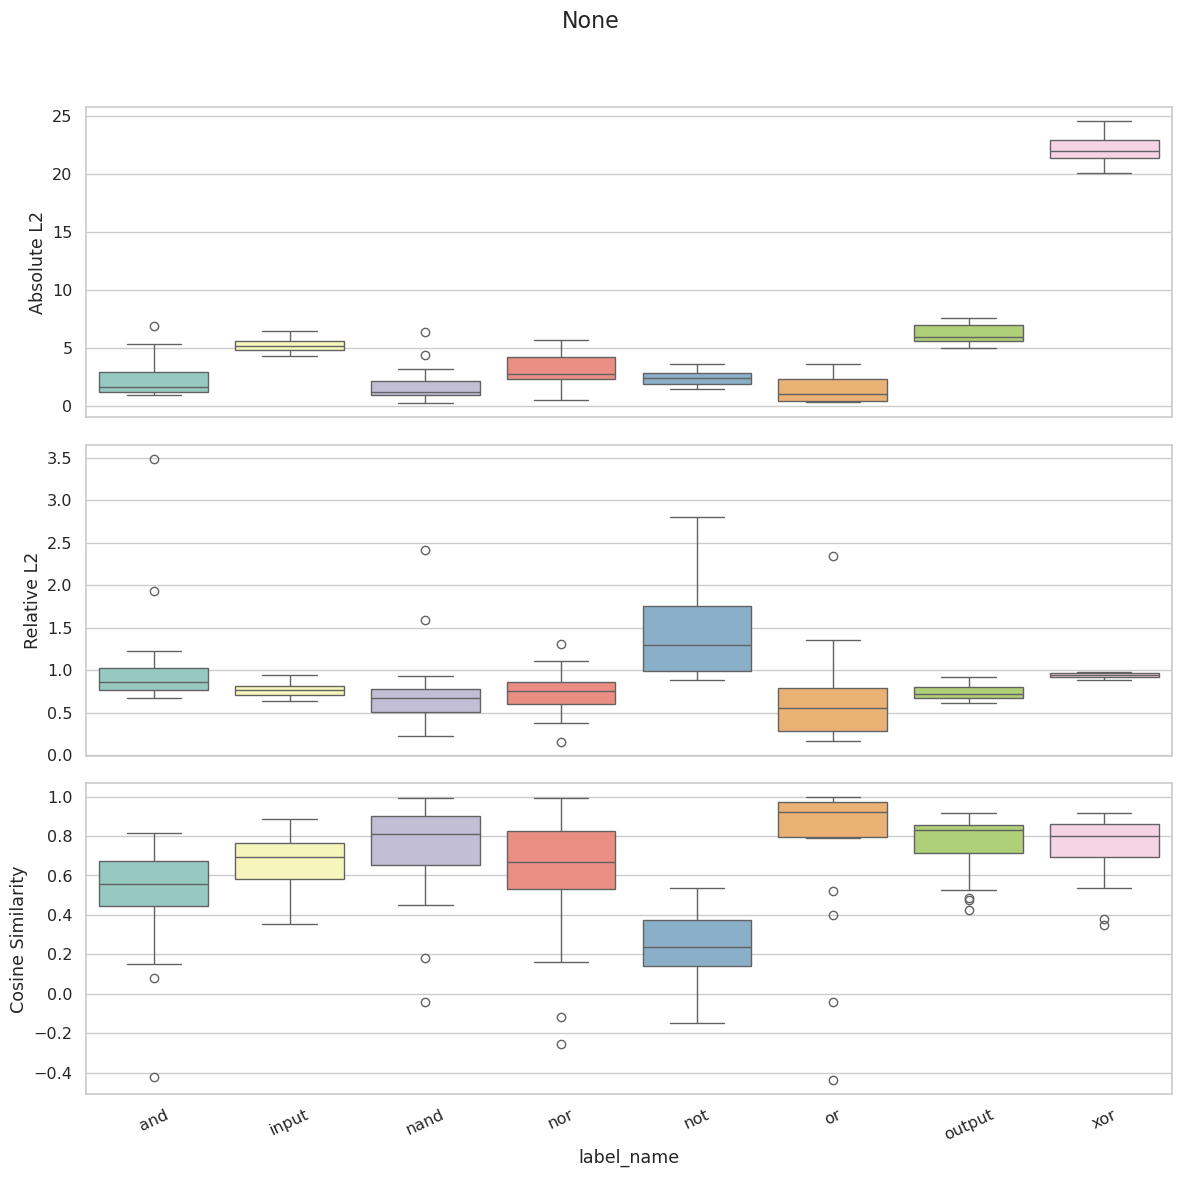


Summary for None:
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.276606  1.541871    20  1.061423  0.632271    20  0.491526   
input        5.260729  0.523064    20  0.767328  0.078851    20  0.675395   
nand         1.811306  1.466285    20  0.768452  0.477102    20  0.725632   
nor          3.035530  1.448231    20  0.742984  0.264765    20  0.600576   
not          2.430037  0.630405    20  1.458293  0.565347    20  0.256930   
or           1.447714  1.139129    20  0.651424  0.506557    20  0.758974   
output       6.265736  0.836566    20  0.745756  0.096251    20  0.756606   
xor         22.058545  1.101236    20  0.939329  0.029295    20  0.739529   

                            
                 std count  
label_name                  
and         0.294946    20  
input       0.139

/tmp/ipykernel_43461/4111151762.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


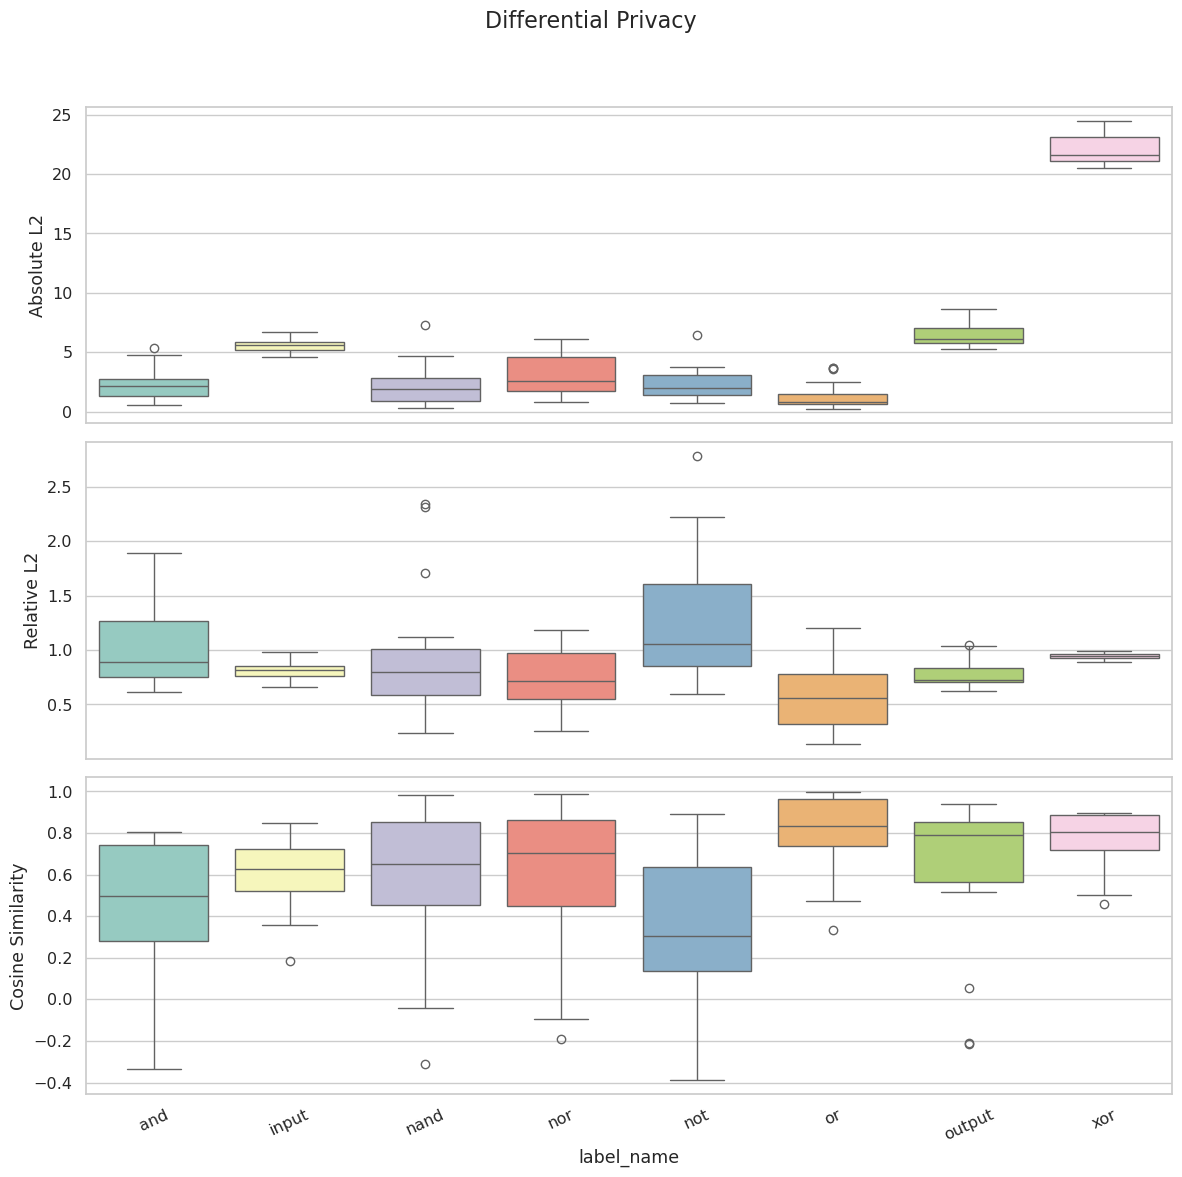


Summary for Differential Privacy:
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.274379  1.244399    20  1.066800  0.456057    20  0.460226   
input        5.575439  0.597604    20  0.812958  0.086705    20  0.605073   
nand         2.224429  1.696086    20  0.939509  0.565363    20  0.599781   
nor          3.046519  1.661924    20  0.741950  0.285327    20  0.618243   
not          2.290573  1.345662    20  1.252014  0.581902    20  0.342513   
or           1.339611  1.125519    20  0.572102  0.277749    20  0.808127   
output       6.544791  1.070514    20  0.779103  0.125526    20  0.631504   
xor         22.158015  1.252172    20  0.943198  0.027311    20  0.765440   

                            
                 std count  
label_name                  
and         0.338361    20  
i

/tmp/ipykernel_43461/4111151762.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


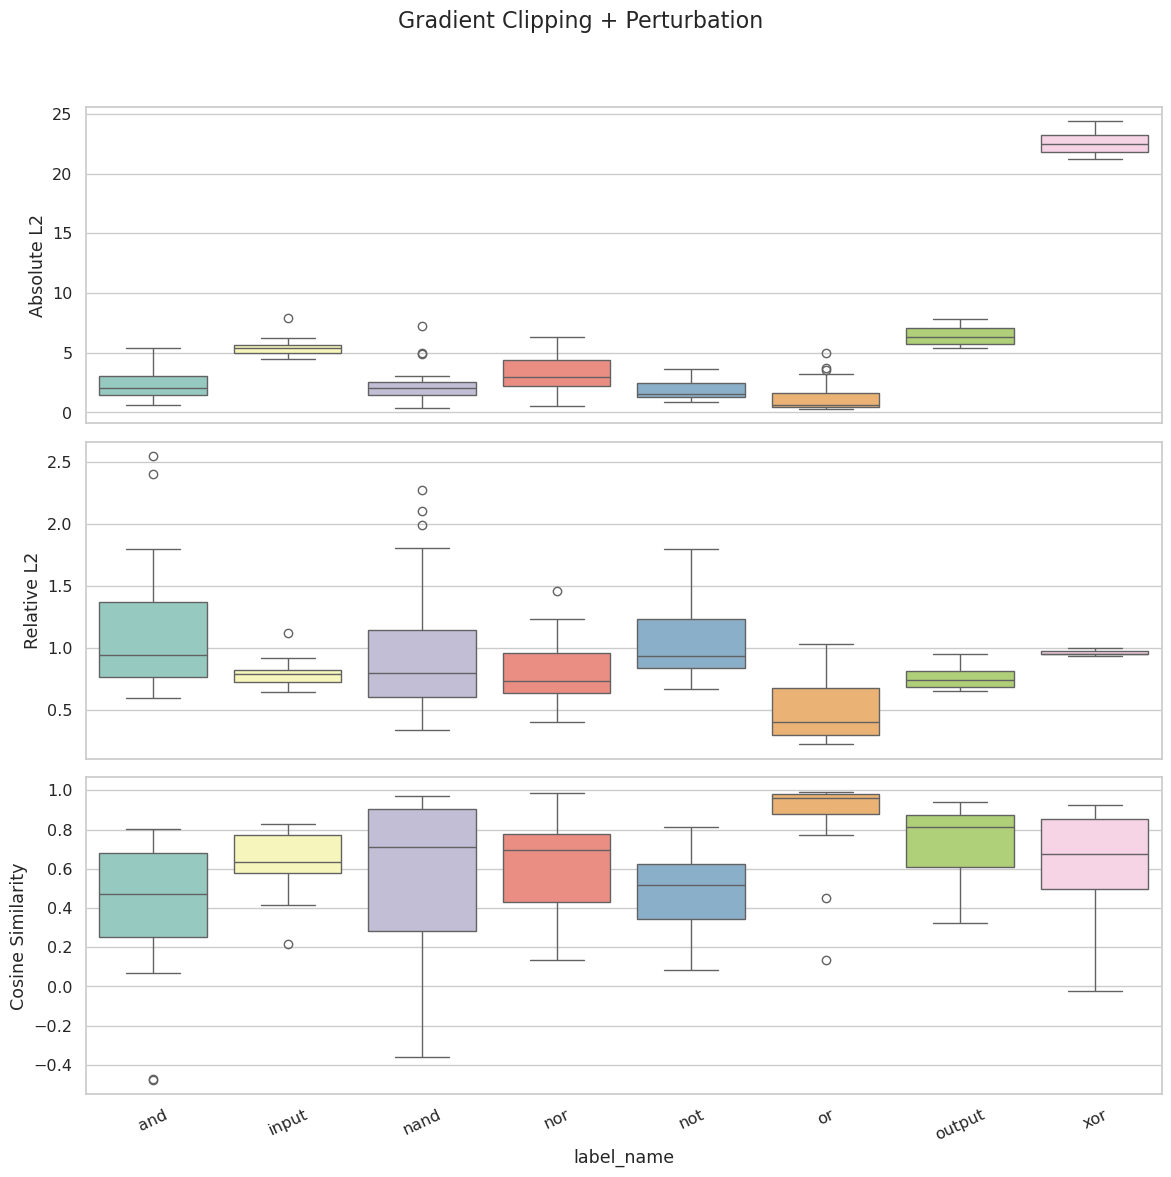


Summary for Gradient Clipping + Perturbation:
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.409182  1.301447    20  1.141404  0.541043    20  0.410362   
input        5.426610  0.743144    20  0.790786  0.103353    20  0.648015   
nand         2.298779  1.681308    20  1.013692  0.599143    20  0.599214   
nor          3.353412  1.622858    20  0.807984  0.257170    20  0.614036   
not          1.894063  0.804840    20  1.056003  0.323152    20  0.487685   
or           1.359691  1.387727    20  0.504747  0.265324    20  0.868682   
output       6.423100  0.832684    20  0.764610  0.096424    20  0.727968   
xor         22.620754  1.003425    20  0.963278  0.021118    20  0.617590   

                            
                 std count  
label_name                  
and         0.3634

/tmp/ipykernel_43461/4111151762.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


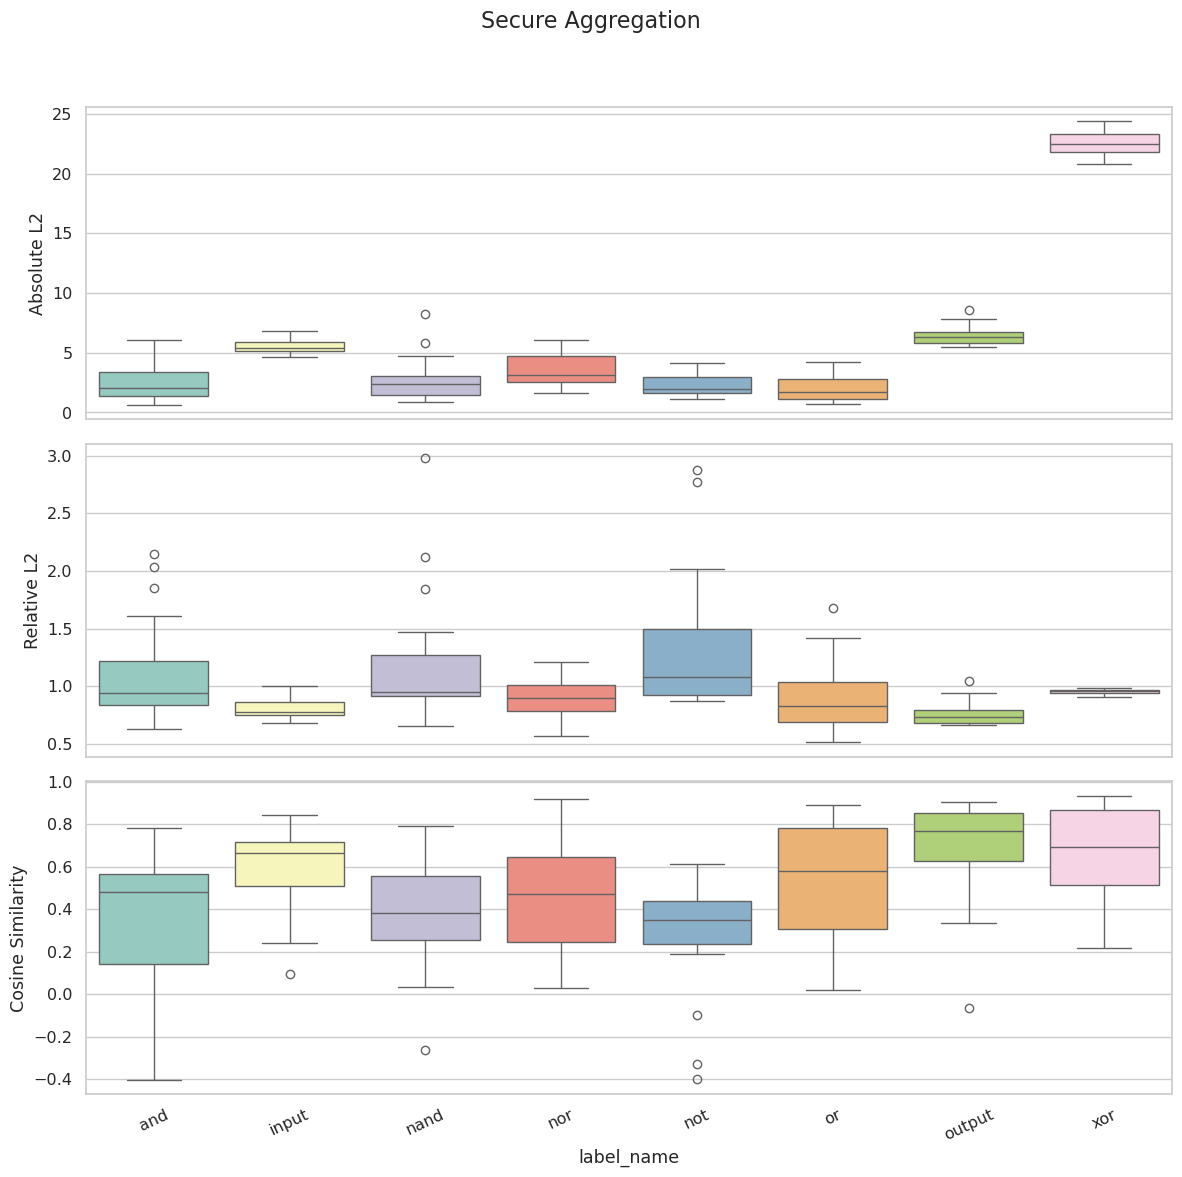


Summary for Secure Aggregation:
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.497152  1.543094    20  1.117825  0.444029    20  0.328843   
input        5.548119  0.596408    20  0.808892  0.086140    20  0.604757   
nand         2.704740  1.847698    20  1.183306  0.558424    20  0.400578   
nor          3.543328  1.362808    20  0.886322  0.179013    20  0.461562   
not          2.317420  0.955331    20  1.339610  0.592725    20  0.285220   
or           2.033432  1.094020    20  0.924277  0.323084    20  0.550123   
output       6.414524  0.829943    20  0.764680  0.105221    20  0.688696   
xor         22.428661  0.979525    20  0.955134  0.021589    20  0.675456   

                            
                 std count  
label_name                  
and         0.354870    20  
inp

/tmp/ipykernel_43461/4111151762.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


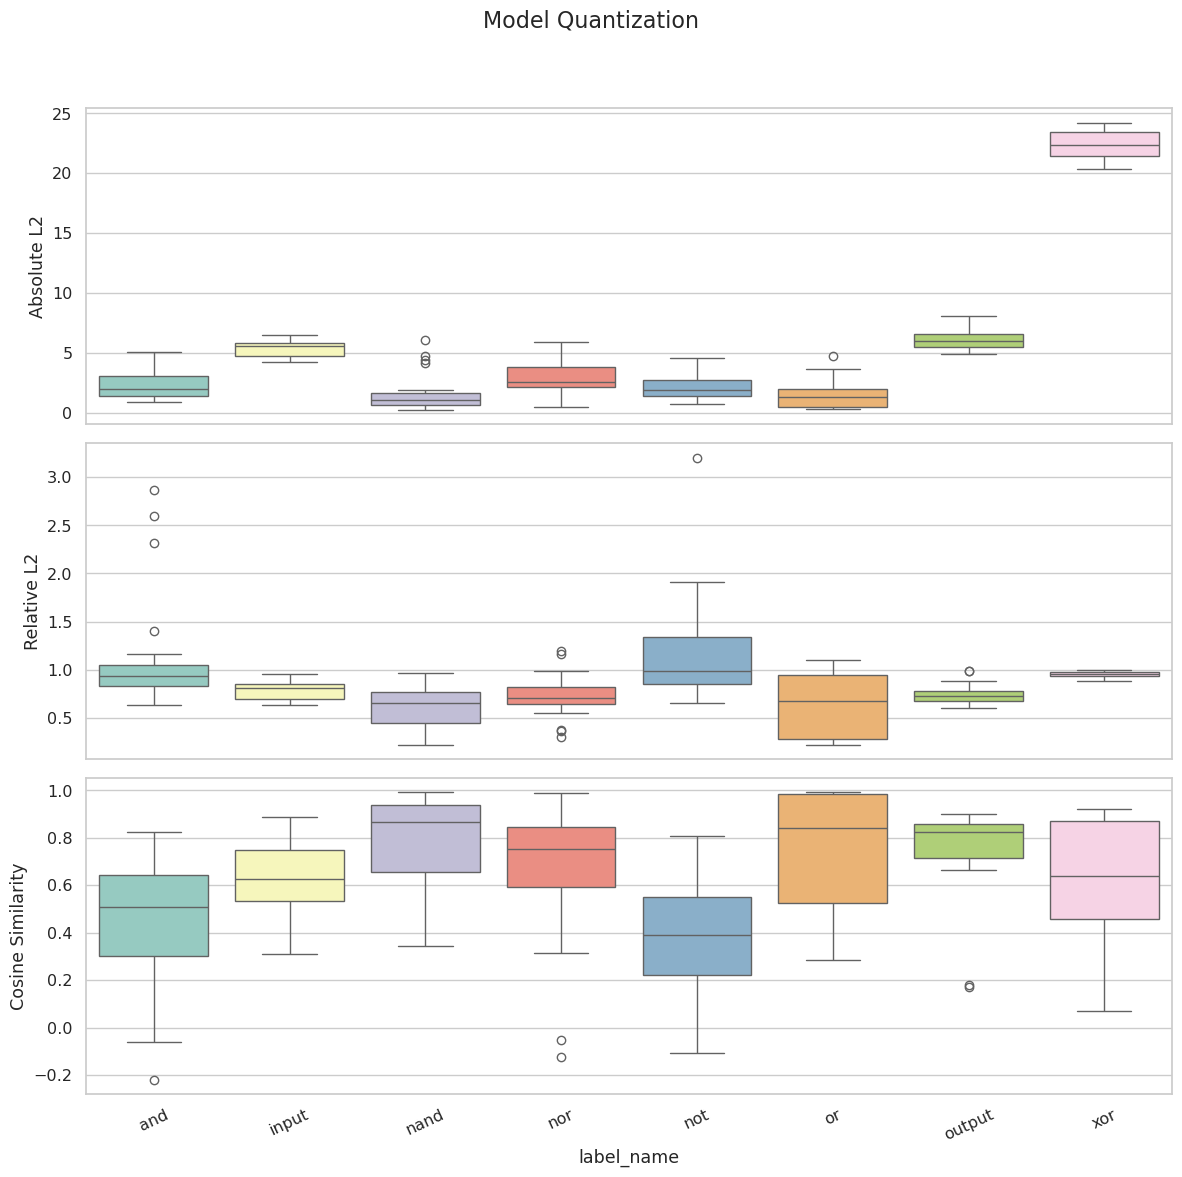


Summary for Model Quantization:
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.394730  1.262983    20  1.171423  0.640706    20  0.429015   
input        5.430084  0.712591    20  0.791295  0.099896    20  0.626584   
nand         1.700894  1.699355    20  0.597980  0.219749    20  0.791217   
nor          3.008023  1.483177    20  0.728543  0.236004    20  0.655865   
not          2.103269  1.031442    20  1.182024  0.586101    20  0.394054   
or           1.566779  1.301262    20  0.636471  0.313470    20  0.768383   
output       6.266793  0.962539    20  0.745022  0.104772    20  0.740110   
xor         22.387453  1.235835    20  0.953139  0.031862    20  0.611660   

                            
                 std count  
label_name                  
and         0.295327    20  
inp

/tmp/ipykernel_43461/4111151762.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_43461/4111151762.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


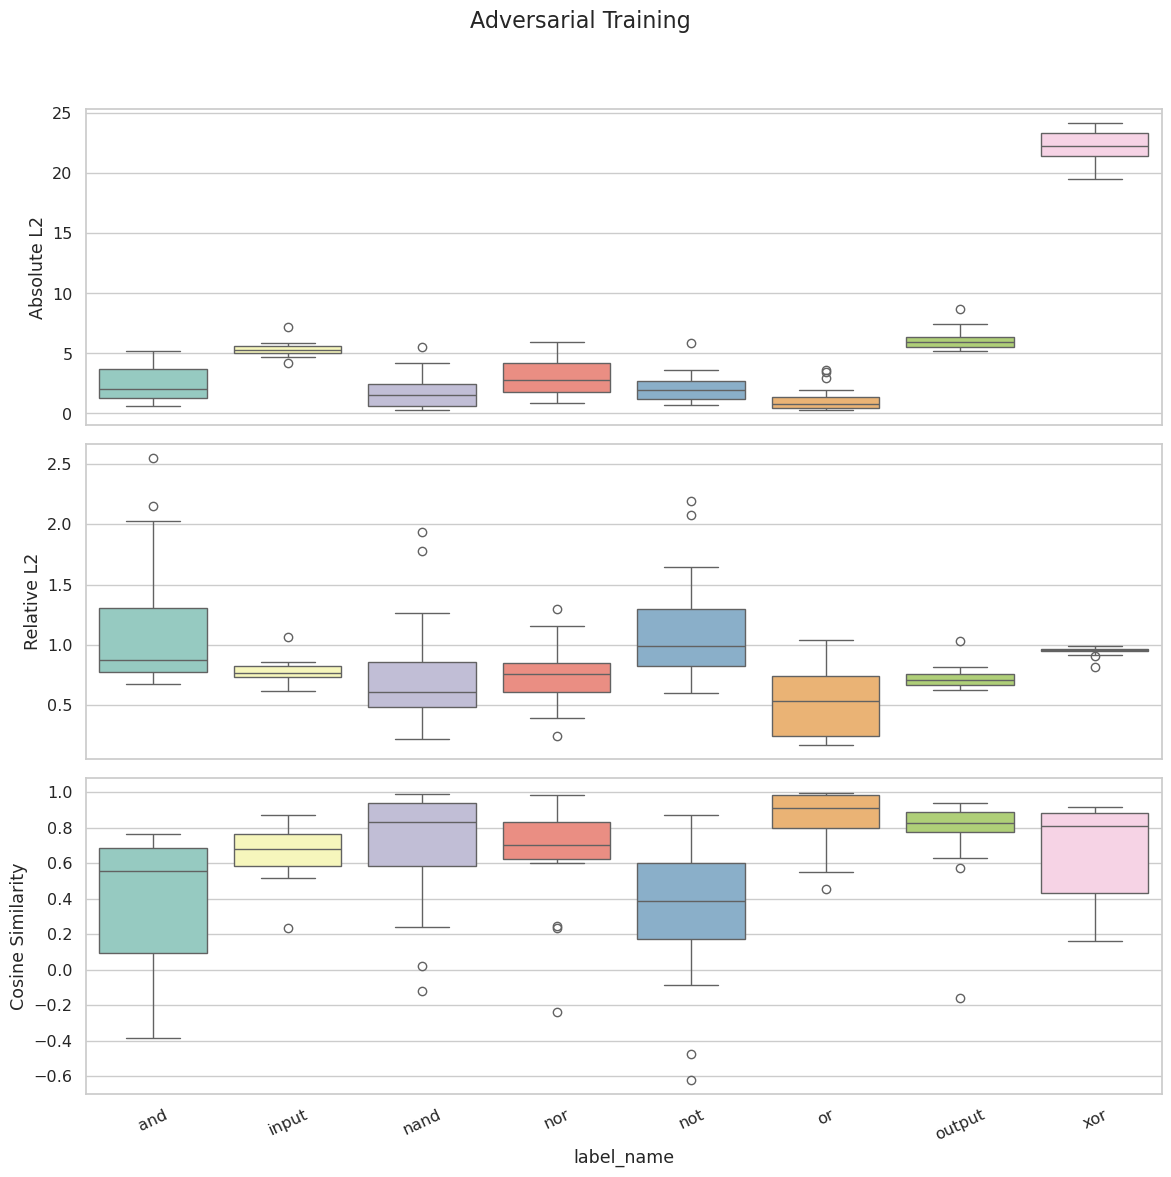


Summary for Adversarial Training:
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.544034  1.598957    20  1.142444  0.552965    20  0.387011   
input        5.375384  0.590474    20  0.783994  0.088258    20  0.661316   
nand         1.867766  1.482777    20  0.746759  0.450446    20  0.700278   
nor          3.031427  1.478131    20  0.741527  0.245190    20  0.658945   
not          2.125463  1.263336    20  1.129893  0.450184    20  0.333946   
or           1.211335  1.039843    20  0.518573  0.277745    20  0.866780   
output       6.140001  0.822780    20  0.730307  0.089078    20  0.767581   
xor         22.293483  1.251503    20  0.949348  0.038220    20  0.686715   

                            
                 std count  
label_name                  
and         0.381092    20  
i

In [10]:
# CELL 8: Final plotting of all saved result CSVs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import numpy as np

sns.set(style="whitegrid", font_scale=1.05)

# find the result files (consistent names from cells above)
files = {
    "None": "results_none.csv",
    "Differential Privacy": "results_dp.csv",
    "Gradient Clipping + Perturbation": "results_gradclip_perturb.csv",
    "Secure Aggregation": "results_secureagg.csv",
    "Model Quantization": "results_quant.csv",
    "Adversarial Training": "results_advtrain.csv"
}

# load each file and plot
for pretty_name, fname in files.items():
    if not os.path.exists(fname):
        print(f"Warning: {fname} not found  skip {pretty_name}")
        continue
    df = pd.read_csv(fname)
    if df.empty:
        print(f"{fname} is empty  skip")
        continue

    # order classes by label
    order = sorted(df["label"].unique())
    label_order = [df[df["label"]==l]["label_name"].iloc[0] for l in order]

    fig, axs = plt.subplots(3,1, figsize=(12,12), sharex=True)
    fig.suptitle(pretty_name, fontsize=16)

    sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
    axs[0].set_ylabel("Absolute L2")
    axs[0].tick_params(axis="x", rotation=25)

    sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
    axs[1].set_ylabel("Relative L2")
    axs[1].tick_params(axis="x", rotation=25)

    sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")
    axs[2].set_ylabel("Cosine Similarity")
    axs[2].tick_params(axis="x", rotation=25)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # print numeric summary
    print(f"\nSummary for {pretty_name}:")
    print(df.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))
